In [1]:
from utils.experiment_utils import get_all_experiments_info, load_best_model
import torch
import os
import hydra
from omegaconf import DictConfig, OmegaConf

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

import ot

from datasets.lineage_tracing import LTSeqDataset

from geomloss import SamplesLoss

In [2]:
pretty_palette = ["#1b718c",
          "#cb4f70",
          "#779e1a",
          "#f49044",
          "#9678b6"]

In [3]:
lts = LTSeqDataset(seed=42)

loading cached adata from ./data/processed/adata_pca_50.h5ad  !!
loading cached clone sets from ./data/processed!
splitting 1218 clones into 609 train and 609 test


In [4]:
configs = get_all_experiments_info('/orcd/data/omarabu/001/gokul/CoupledDistributionEmbeddings/outputs/', False)

cfgs = [c for c in configs if 'lts' in c['name']]

cfgs


[{'name': 'lts_70643ee733d7dacdc6254c59a37920b5',
  'dir': '/orcd/data/omarabu/001/gokul/CoupledDistributionEmbeddings/outputs/lts_70643ee733d7dacdc6254c59a37920b5',
  'config': {'dataset': {'_target_': 'datasets.lineage_tracing.LTSeqDataset', 'set_size': 100, 'min_cells': 3, 'data_shape': [50], 'root': '/orcd/data/omarabu/001/gokul/CoupledDistributionEmbeddings/data', 'seed': '${seed}'}, 'encoder': {'_target_': 'encoder.encoders.DistributionEncoderGNN', 'in_dim': '${dataset.data_shape[0]}', 'latent_dim': '${experiment.latent_dim}', 'hidden_dim': '${experiment.hidden_dim}', 'set_size': '${experiment.set_size}', 'layers': 2, 'fc_layers': 2}, 'model': {'_target_': 'layers.MLP', 'in_dims': [50, 128, 128, 128], 'hidden_dim': 512, 'out_dim': 50, 'layers': 4}, 'coupling': {'_target_': 'types.NoneType'}, 'generator': {'_target_': 'generator.energy.EnergyGenerator', 'model': '${model}', 'noise_dim': '${experiment.latent_dim}', 'sigma_min': 1.0, 'm': 8, 'lambda_energy': 1.0}, 'optimizer': {'_ta

In [14]:
print(lts.test_src_meta[0])

['10', '4.0', 'set1']


In [11]:
def load_model(cfg, path, device):
    enc = hydra.utils.instantiate(cfg['encoder'])
    gen = hydra.utils.instantiate(cfg['generator'])
    state = load_best_model(path)
    enc.load_state_dict(state['encoder_state_dict'])
    gen.load_state_dict(state['generator_state_dict'])
    enc.eval()
    gen.eval()
    enc.to(device)
    gen.to(device)
    return enc, gen

enc, gen = load_model(cfgs[1]['config'], cfgs[1]['dir'], 'cuda')

In [12]:
with torch.no_grad():
    z_x = enc(lts.test_srcs.cuda())
    z_y = enc(lts.test_tgts.cuda())

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

# 1) get numpy embeddings and torch samples
X = z_x.cpu().numpy()
Y = z_y.cpu().numpy()
src = lts.test_srcs      # torch.Tensor of shape (N, …)
tgt = lts.test_tgts      # torch.Tensor of shape (N, …)

# 2) split indices
n = X.shape[0]
idx = np.arange(n)
train_idx, test_idx = train_test_split(idx, test_size=0.5, random_state=42)

X_train, Y_train = X[train_idx], Y[train_idx]
X_test,  Y_test  = X[test_idx],  Y[test_idx]

src_test = src[test_idx]
z_x_test = z_x[test_idx]
tgt_test = tgt[test_idx]

# 3) fit ridge on train
alphas = np.logspace(-6, 6, 25)
ridge = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')
ridge.fit(X_train, Y_train)
print("best alpha:", ridge.alpha_)

# 4) eval on test
Y_pred_test = ridge.predict(X_test)
print("Test MSE:", mean_squared_error(Y_test, Y_pred_test))
print("Test R2:",  r2_score(Y_test, Y_pred_test, multioutput='variance_weighted'))

# 5) generate held‐out y_hat and compute EMD
y_hat_test = gen(
    src_test.cuda().reshape(-1, 50),
    z_x_test.cuda(),
    torch.tensor(Y_pred_test).cuda()
).reshape(tgt_test.shape)

loss = SamplesLoss("energy")

energies = loss(y_hat_test.cuda(), tgt_test.cuda())

energy = energies.mean()

print('Energy distance on held-out test:', energy.item())

best alpha: 0.31622776601683794
Test MSE: 0.0021603028289973736
Test R2: 0.38788363337516785
Energy distance on held-out test: 3.227698564529419


/tmp/ipykernel_1955094/2192582128.py:3: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.kdeplot(x=energies.cpu().numpy(), hue=times, common_norm=False,


<Axes: ylabel='Density'>

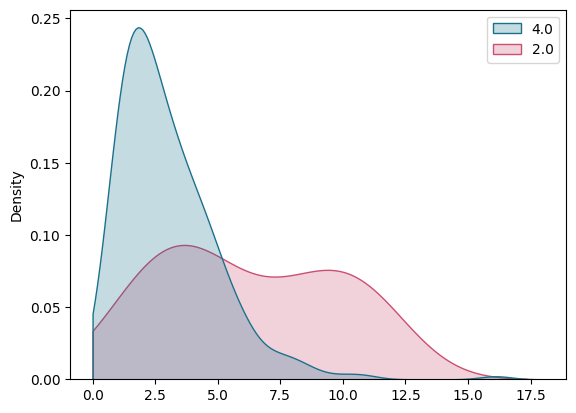

In [9]:
times = [lts.test_src_meta[test_idx[i]][1] for i in range(len(test_idx))]

sns.kdeplot(x=energies.cpu().numpy(), hue=times, common_norm=False,
            clip=(0, None), palette=pretty_palette, fill=True)

Clone: 5490, Time: 4
Clone: 5490, Time: 4


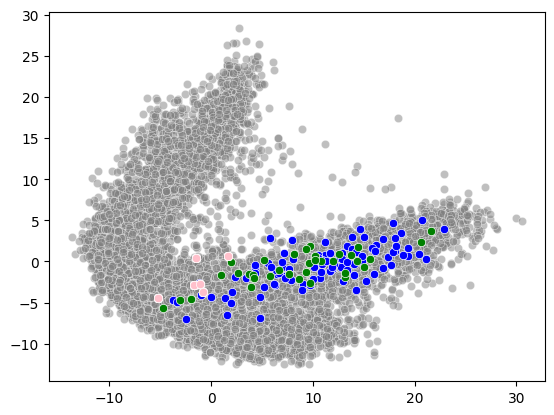

Clone: 1461, Time: 4
Clone: 1461, Time: 4


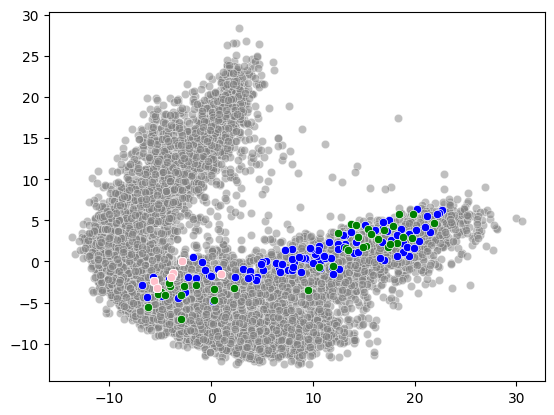

Clone: 2189, Time: 4
Clone: 2189, Time: 4


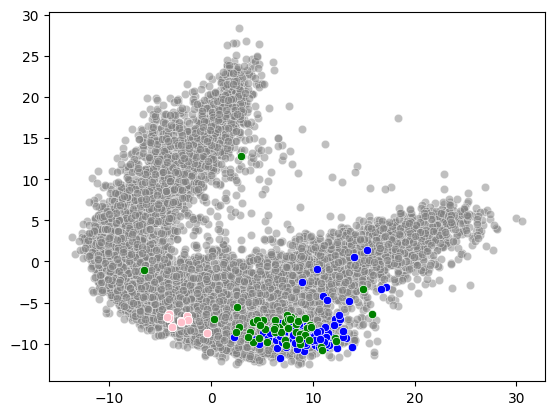

Clone: 675, Time: 4
Clone: 675, Time: 4


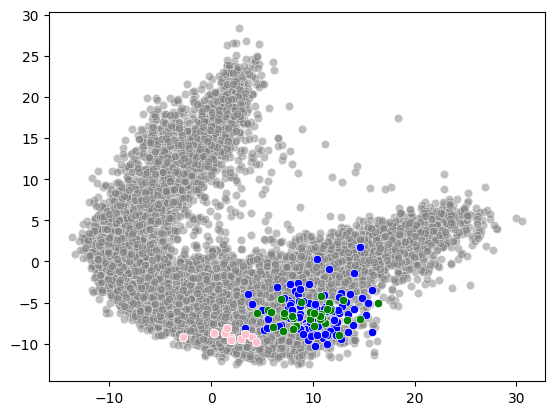

Clone: 5075, Time: 4
Clone: 5075, Time: 4


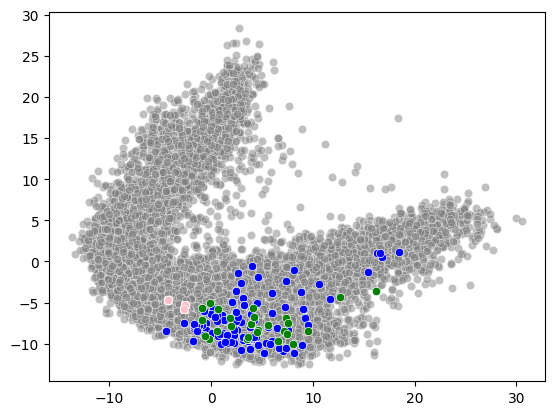

Clone: 5714, Time: 4
Clone: 5714, Time: 4


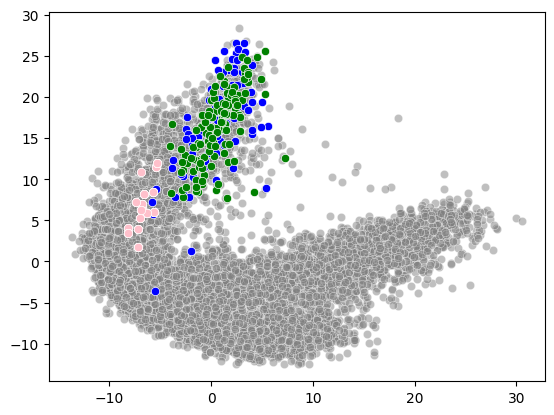

Clone: 3093, Time: 4
Clone: 3093, Time: 4


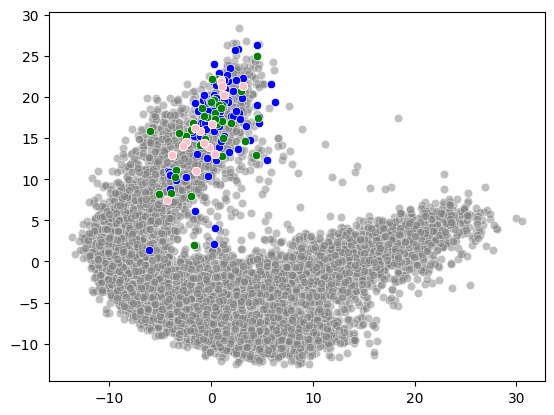

Clone: 5591, Time: 4
Clone: 5591, Time: 4


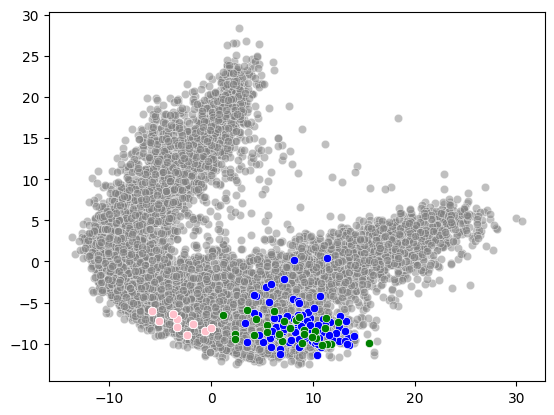

Clone: 5483, Time: 4
Clone: 5483, Time: 4


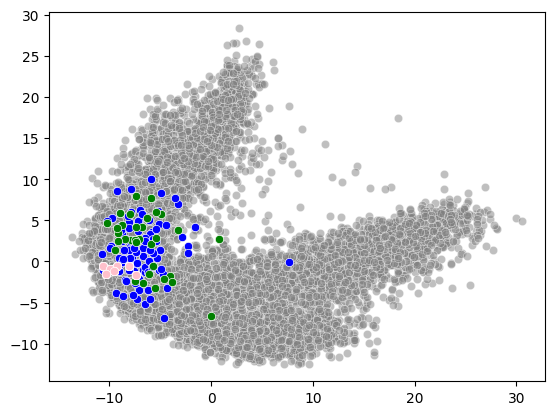

Clone: 4042, Time: 4
Clone: 4042, Time: 4


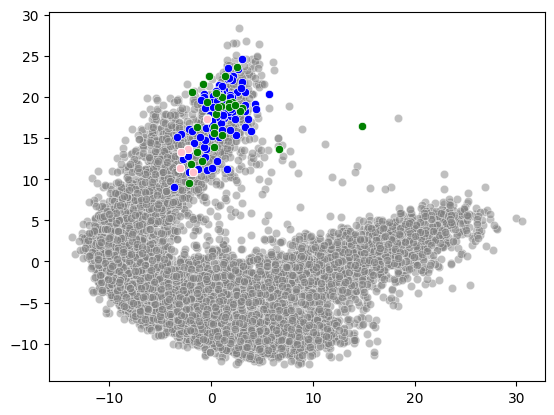

Clone: 3682, Time: 4
Clone: 3682, Time: 4


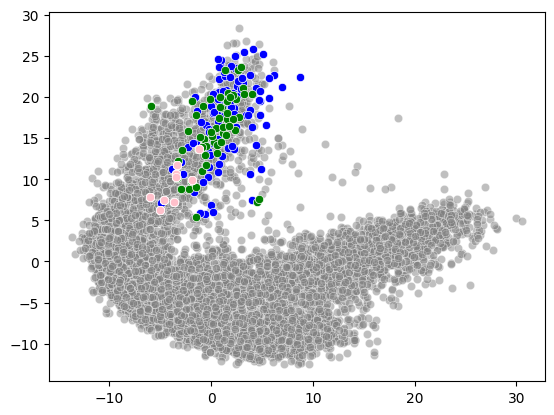

In [10]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=2).fit(lts.adata.obsm['X_pca'][:, :2])

to_plot = lts.adata[np.random.choice(lts.adata.shape[0], 10000, replace=False)]

for i in range(252):#np.random.choice(252, 10, replace=False):


    metadata = lts.test_src_meta[test_idx[i]]
    clone = int(metadata[0])
    time = int(float(metadata[1]))

    if energies[i] < 0.75:# and time < 4:

        true_targets = lts.adata[lts.adata.obs['clone'] == clone]
        true_targets = true_targets[true_targets.obs['time'] == time + 2]

        predicted_pcs = y_hat_test[i].cpu().numpy()

        # print(len(predicted_pcs))

        # distances, indices = nbrs.kneighbors(predicted_pcs[:, :2])
        # neighbors = lts.adata[indices[0]]



        print(f'Clone: {clone}, Time: {time}')

        print(f'Clone: {clone}, Time: {time}')

        # sns.scatterplot(x=lts.adata.obs['SPRING1'],
        #                 y=lts.adata.obs['SPRING2'],
        #                 # hue=lts.adata.obs['t'],
        #                 palette='tab10',
        #                 alpha=0.1)
        
        # sns.scatterplot(x=true_targets.obs['SPRING1'],
        #                 y=true_targets.obs['SPRING2'],
        #                 color='green',)

        # sns.scatterplot(x=neighbors.obs['SPRING1'],
        #                 y=neighbors.obs['SPRING2'],
        #                 color='red',)

        sns.scatterplot(x=to_plot.obsm['X_pca'][:, 0],
                        y=to_plot.obsm['X_pca'][:, 1],
                        color='gray', alpha=0.5)
        
        sns.scatterplot(x=predicted_pcs[:, 0],
                        y=predicted_pcs[:, 1],
                        color='blue',)
        
        sns.scatterplot(x=true_targets.obsm['X_pca'][:, 0],
                        y=true_targets.obsm['X_pca'][:, 1],
                        color='green',)
        
        sns.scatterplot(x=src_test.cpu().numpy()[i, :, 0],
                        y=src_test.cpu().numpy()[i, :, 1],
                        color='pink',)


        plt.show()


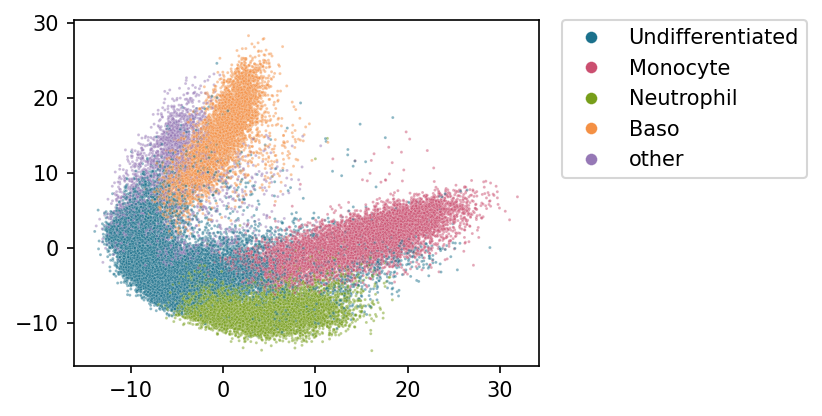

In [11]:
# if type count is less than 5k, reassign type to 'other'

counts = lts.adata.obs['type'].value_counts()
lts.adata.obs['type'] = lts.adata.obs['type'].apply(lambda x: x if counts[x] >= 5000 else 'other')

plt.figure(figsize=(4, 3), dpi=150)

sns.scatterplot(x=lts.adata.obsm['X_pca'][:, 0],
                y=lts.adata.obsm['X_pca'][:, 1],
                hue=lts.adata.obs['type'], s=2, 
                alpha=0.5, palette=pretty_palette)

# legend to side, with marker sizes 10 and transparency 1
leg = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
              borderaxespad=0., markerscale=4, )
for lh in leg.legend_handles: 
    lh.set_alpha(1)

In [12]:
lts.n_sets

4830